# Required Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math
from sklearn.model_selection import TimeSeriesSplit, StratifiedGroupKFold, cross_val_score, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, make_scorer, fbeta_score, precision_score, recall_score
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight

# EDA: Weather 

## Preprocessing Weather: Load in Data

In [2]:
# Only select the years 2019, 2022, 2023, 2024, and 2025 
files_and_ranges = [
    ("I:/Weather 2019-2025/uurgeg_260_2011-2020.txt", "2019-01-01", "2019-12-31"),
    ("I:/Weather 2019-2025/uurgeg_260_2021-2030.txt", "2022-01-01", "2025-12-31"),
]

weather = pd.concat(
    [
        pd.read_csv(
            path,
            sep=",",
            skiprows=30,
            parse_dates=["YYYYMMDD"],
            low_memory=False
        ).loc[lambda d: d["YYYYMMDD"].between(start, end)]
        for path, start, end in files_and_ranges
    ],
    ignore_index=True
)

In [3]:
weather.columns = weather.columns.str.strip().str.lstrip("#").str.strip()

weather = (
    weather.rename(columns={
        "STN": "Station",
        "YYYYMMDD": "Date",
        "HH": "Hour",
        "DD": "Wind Direction",
        "FH": "Hourly Mean Wind Speed",
        "FF": "Wind Speed last 10 Minutes",
        "FX": "Max Wind Speed",
        "T": "Temperature",
        "T10N": "Min Temperature",
        "TD": "Dew Point temperature",
        "SQ": "Sunshine Duration",
        "Q": "Global Radiation",
        "DR": "Precipitation Duration",
        "RH": "Precipitation Amount",
        "P": "Air Pressure",
        "VV": "Horizontal Visibility",
        "N": "Cloud Cover",
        "U": "Humidity",
        "WW": "Weather Code",
        "IX": "Indicator weather code",
        "M": "Fog",
        "R": "Rainfall",
        "S": "Snowfall",
        "O": "Thunder",
        "Y": "Hail",
    })
)

num_cols = weather.columns.drop("Date")
weather[num_cols] = weather[num_cols].apply(pd.to_numeric, errors="coerce", downcast="float")

## Preprocessing Weather: Analyzing the Data

In [4]:
weather.head()

,Station,Date,Hour,Wind Direction,Hourly Mean Wind Speed,Wind Speed last 10 Minutes,Max Wind Speed,Temperature,Min Temperature,Dew Point temperature,...,Horizontal Visibility,Cloud Cover,Humidity,Weather Code,Indicator weather code,Fog,Rainfall,Snowfall,Thunder,Hail
0,260.0,2019-01-01,1.0,230.0,30.0,20.0,60.0,79.0,NaN,63.0,...,36.0,8.0,89.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0
1,260.0,2019-01-01,2.0,250.0,30.0,30.0,70.0,84.0,NaN,56.0,...,41.0,8.0,82.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0
2,260.0,2019-01-01,3.0,250.0,40.0,40.0,90.0,84.0,NaN,57.0,...,57.0,8.0,83.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0
3,260.0,2019-01-01,4.0,250.0,40.0,40.0,80.0,82.0,NaN,56.0,...,62.0,8.0,83.0,NaN,5.0,0.0,0.0,0.0,0.0,0.0
4,260.0,2019-01-01,5.0,260.0,40.0,40.0,90.0,84.0,NaN,53.0,...,71.0,8.0,80.0,NaN,5.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Display basic information about the DataFrame: 
# number of rows, columns, data types, and non-null counts

weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Station                     43824 non-null  float32       
 1   Date                        43824 non-null  datetime64[us]
 2   Hour                        43824 non-null  float32       
 3   Wind Direction              43824 non-null  float32       
 4   Hourly Mean Wind Speed      43824 non-null  float32       
 5   Wind Speed last 10 Minutes  43824 non-null  float32       
 6   Max Wind Speed              43824 non-null  float32       
 7   Temperature                 43824 non-null  float32       
 8   Min Temperature             7304 non-null   float32       
 9   Dew Point temperature       43824 non-null  float32       
 10  Sunshine Duration           43824 non-null  float32       
 11  Global Radiation            43824 non-null  float32       
 12  P

In [6]:
weather.describe()

,Station,Date,Hour,Wind Direction,Hourly Mean Wind Speed,Wind Speed last 10 Minutes,Max Wind Speed,Temperature,Min Temperature,Dew Point temperature,...,Horizontal Visibility,Cloud Cover,Humidity,Weather Code,Indicator weather code,Fog,Rainfall,Snowfall,Thunder,Hail
count,43824.0,43824,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,7304.000000,43824.000000,...,43824.000000,43779.000000,43824.000000,3557.000000,8760.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000
mean,260.0,2023-02-06 09:07:17.677984,12.500000,193.732437,33.104237,33.233845,65.038338,115.510246,85.876366,76.829407,...,66.412422,6.045570,78.940605,30.381220,5.812329,0.043926,0.206759,0.004906,0.007393,0.006891
min,260.0,2019-01-01 00:00:00,1.000000,0.000000,0.000000,0.000000,0.000000,-78.000000,-107.000000,-126.000000,...,0.000000,0.000000,18.000000,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,260.0,2022-04-02 00:00:00,6.750000,130.000000,20.000000,20.000000,40.000000,69.000000,41.000000,38.000000,...,62.000000,4.000000,69.000000,10.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,260.0,2023-07-02 12:00:00,12.500000,200.000000,30.000000,30.000000,60.000000,112.000000,84.000000,79.000000,...,70.000000,8.000000,83.000000,23.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,260.0,2024-10-01 00:00:00,18.250000,250.000000,40.000000,40.000000,80.000000,162.000000,133.000000,119.000000,...,80.000000,8.000000,92.000000,51.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,260.0,2025-12-31 00:00:00,24.000000,990.000000,150.000000,180.000000,310.000000,372.000000,345.000000,235.000000,...,83.000000,9.000000,100.000000,92.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,0.0,NaN,6.922266,119.406776,17.528082,18.085651,34.058723,66.438766,66.978317,54.305199,...,17.493359,3.050379,16.308069,25.683256,0.982288,0.204932,0.404986,0.069872,0.085666,0.082728


## Preprocessing Weather: Dealing with Missing Values

In [7]:
# Check for duplicates
weather.duplicated().sum()

np.int64(0)

In [8]:
total = weather.isnull().sum().sort_values(ascending=False)
percent = (weather.isnull().sum()/weather.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data

,Total,Percent
Weather Code,40267,0.918834
Min Temperature,36520,0.833333
Indicator weather code,35064,0.800110
Cloud Cover,45,0.001027
Station,0,0.000000
Hourly Mean Wind Speed,0,0.000000
Date,0,0.000000
Wind Direction,0,0.000000
Hour,0,0.000000
Temperature,0,0.000000


In [9]:
# Keep missing values 'weather code' and 'Indicator weather code' as it is, since NaN indicates 'No significant weather / not recorded' and is meaningful information for the analysis.
# 'Cloud Cover' has 9% missing values, but I will keep it as it is since NaN

# Drop station because all stations are 260, redundant for analysis. 
weather = weather.drop(columns=['Station', 'Min Temperature', 'Weather Code', 'Indicator weather code'])


## Preprocessing Weather: Univariate & Bivariate Analysis

### Preprocessing Weather: Univariate

In [10]:
weather.describe()

,Date,Hour,Wind Direction,Hourly Mean Wind Speed,Wind Speed last 10 Minutes,Max Wind Speed,Temperature,Dew Point temperature,Sunshine Duration,Global Radiation,...,Precipitation Amount,Air Pressure,Horizontal Visibility,Cloud Cover,Humidity,Fog,Rainfall,Snowfall,Thunder,Hail
count,43824,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,...,43824.000000,43824.000000,43824.000000,43779.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000
mean,2023-02-06 09:07:17.677984,12.500000,193.732437,33.104237,33.233845,65.038338,115.510246,76.829407,2.242333,46.340794,...,0.977113,10152.021484,66.412422,6.045570,78.940605,0.043926,0.206759,0.004906,0.007393,0.006891
min,2019-01-01 00:00:00,1.000000,0.000000,0.000000,0.000000,0.000000,-78.000000,-126.000000,0.000000,0.000000,...,-1.000000,9695.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2022-04-02 00:00:00,6.750000,130.000000,20.000000,20.000000,40.000000,69.000000,38.000000,0.000000,0.000000,...,0.000000,10087.000000,62.000000,4.000000,69.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2023-07-02 12:00:00,12.500000,200.000000,30.000000,30.000000,60.000000,112.000000,79.000000,0.000000,2.000000,...,0.000000,10158.000000,70.000000,8.000000,83.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2024-10-01 00:00:00,18.250000,250.000000,40.000000,40.000000,80.000000,162.000000,119.000000,3.000000,66.000000,...,0.000000,10223.000000,80.000000,8.000000,92.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2025-12-31 00:00:00,24.000000,990.000000,150.000000,180.000000,310.000000,372.000000,235.000000,10.000000,338.000000,...,326.000000,10450.000000,83.000000,9.000000,100.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,NaN,6.922266,119.406776,17.528082,18.085651,34.058723,66.438766,54.305199,3.673042,74.451508,...,5.638997,106.615303,17.493359,3.050379,16.308069,0.204932,0.404986,0.069872,0.085666,0.082728


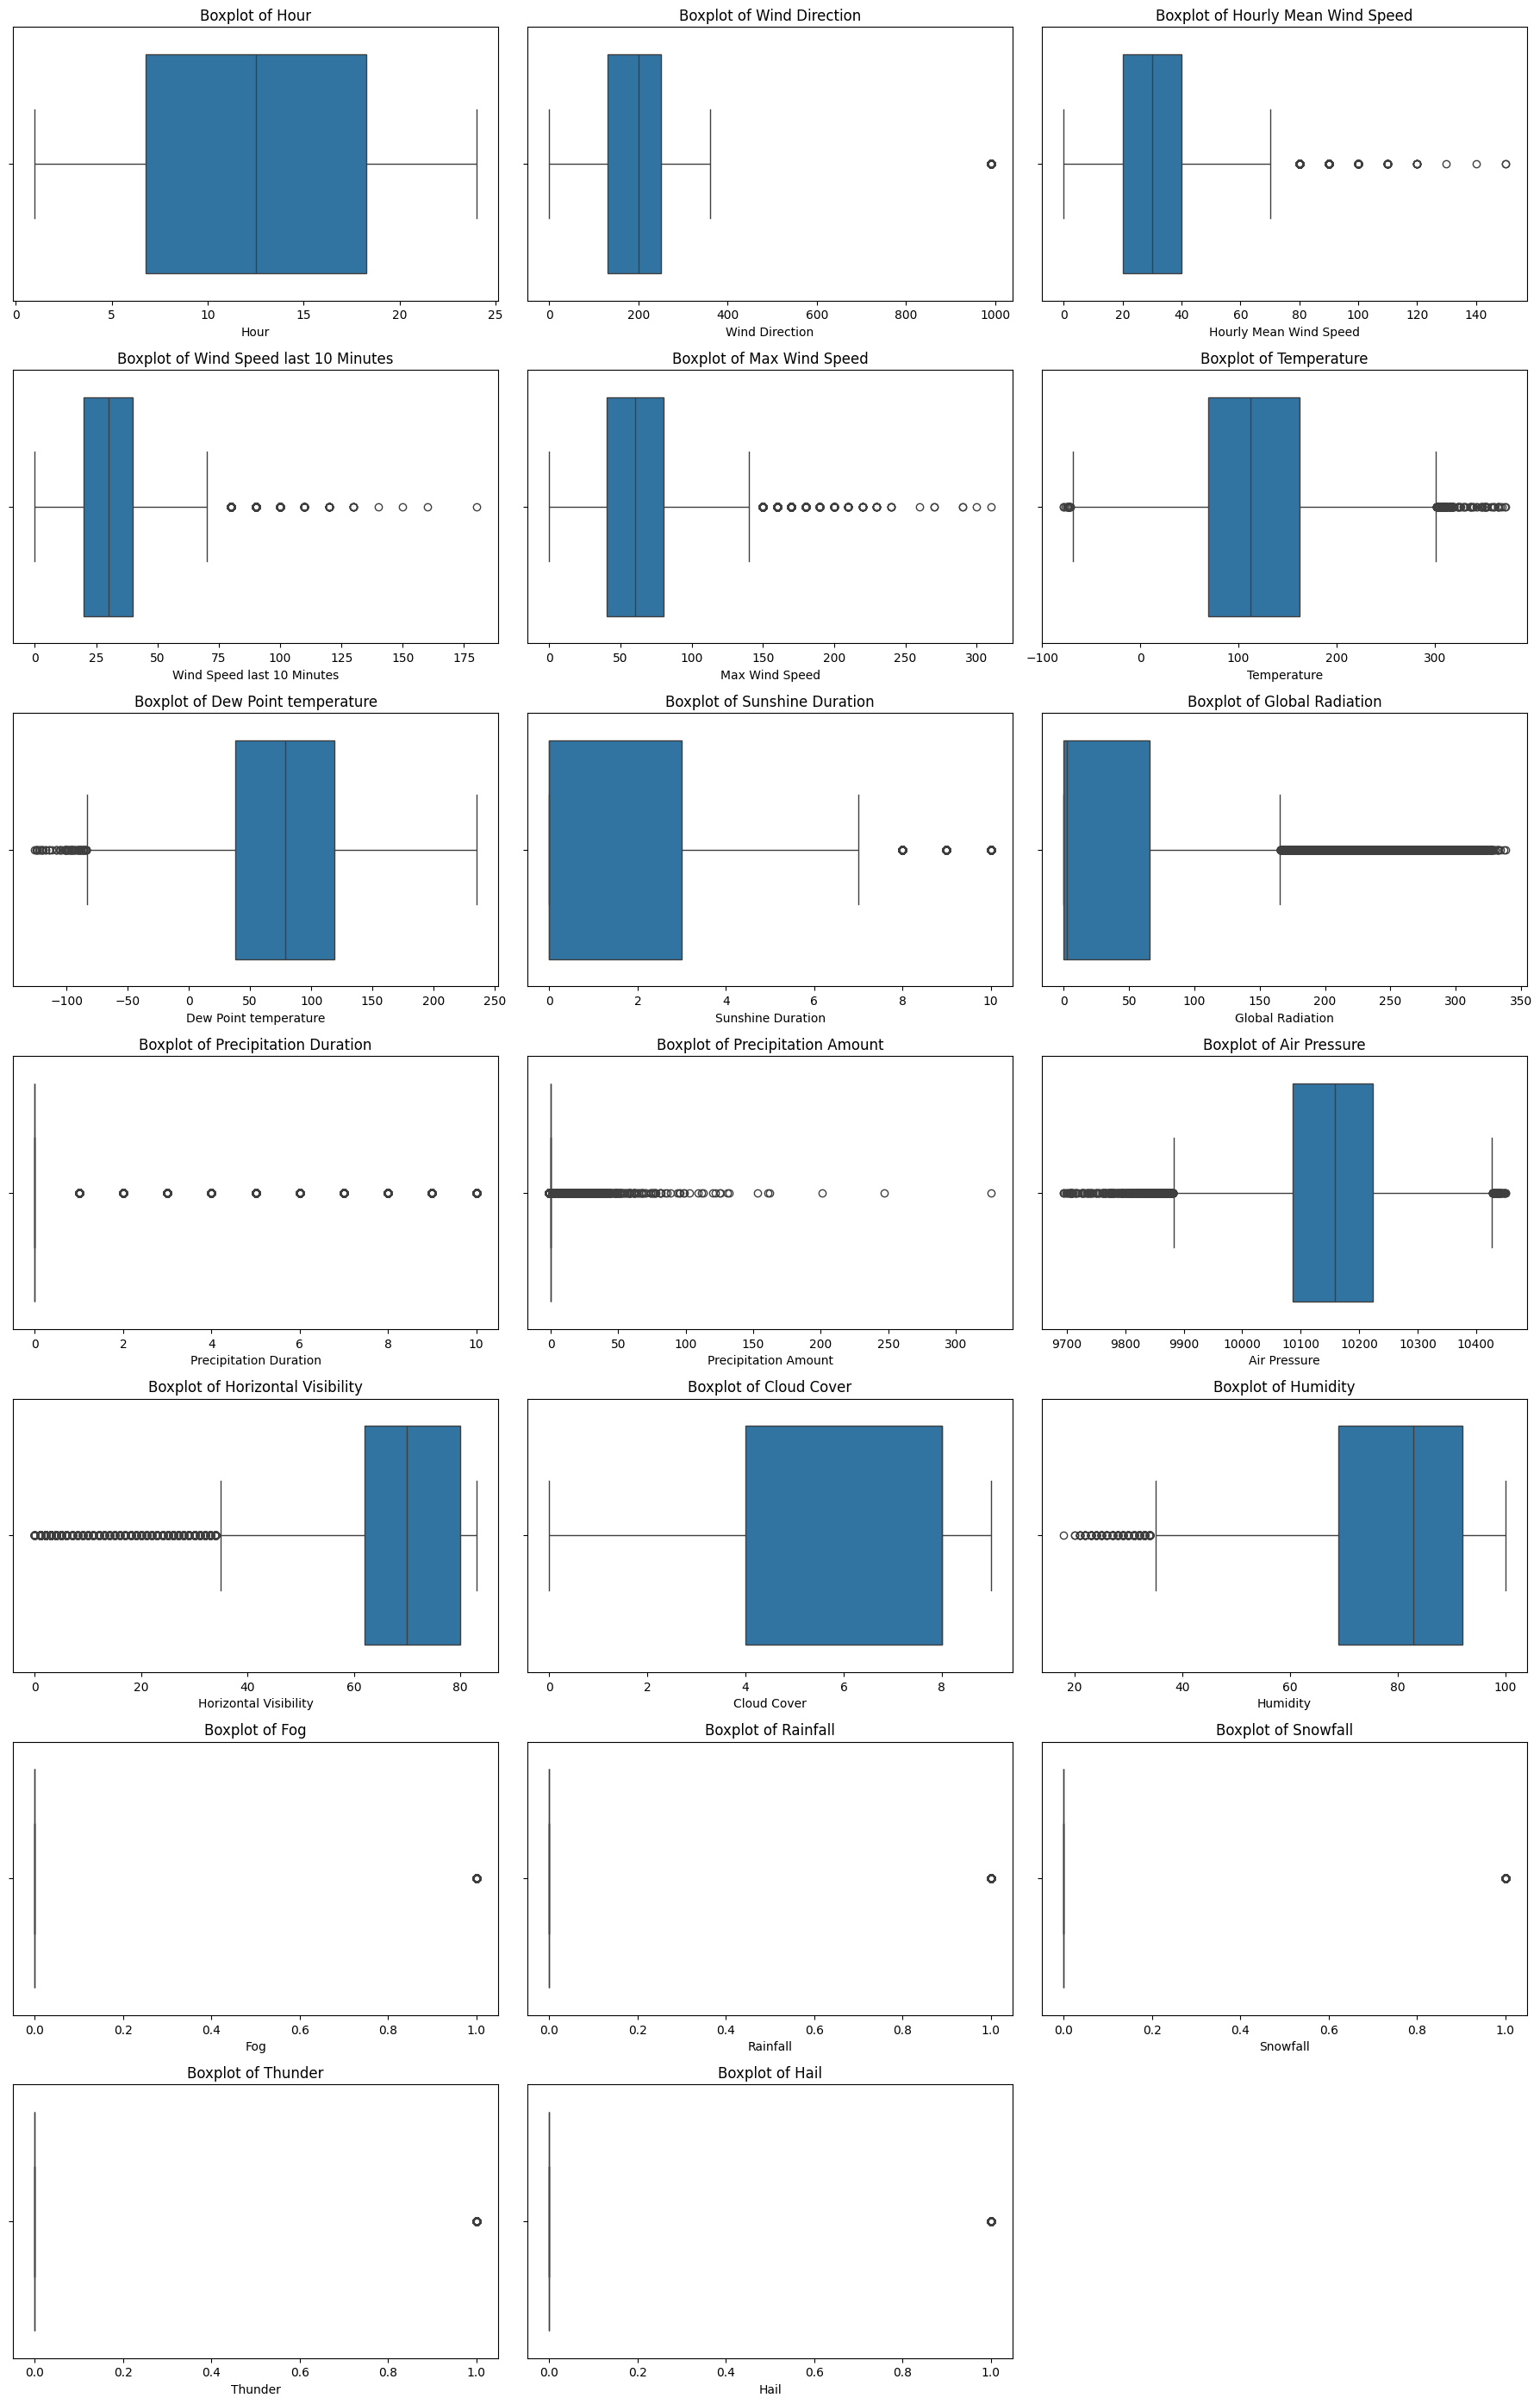

In [11]:
#boxplot: for outliers and data spread
num_cols = weather.select_dtypes(include=[np.number]).columns
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=weather[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

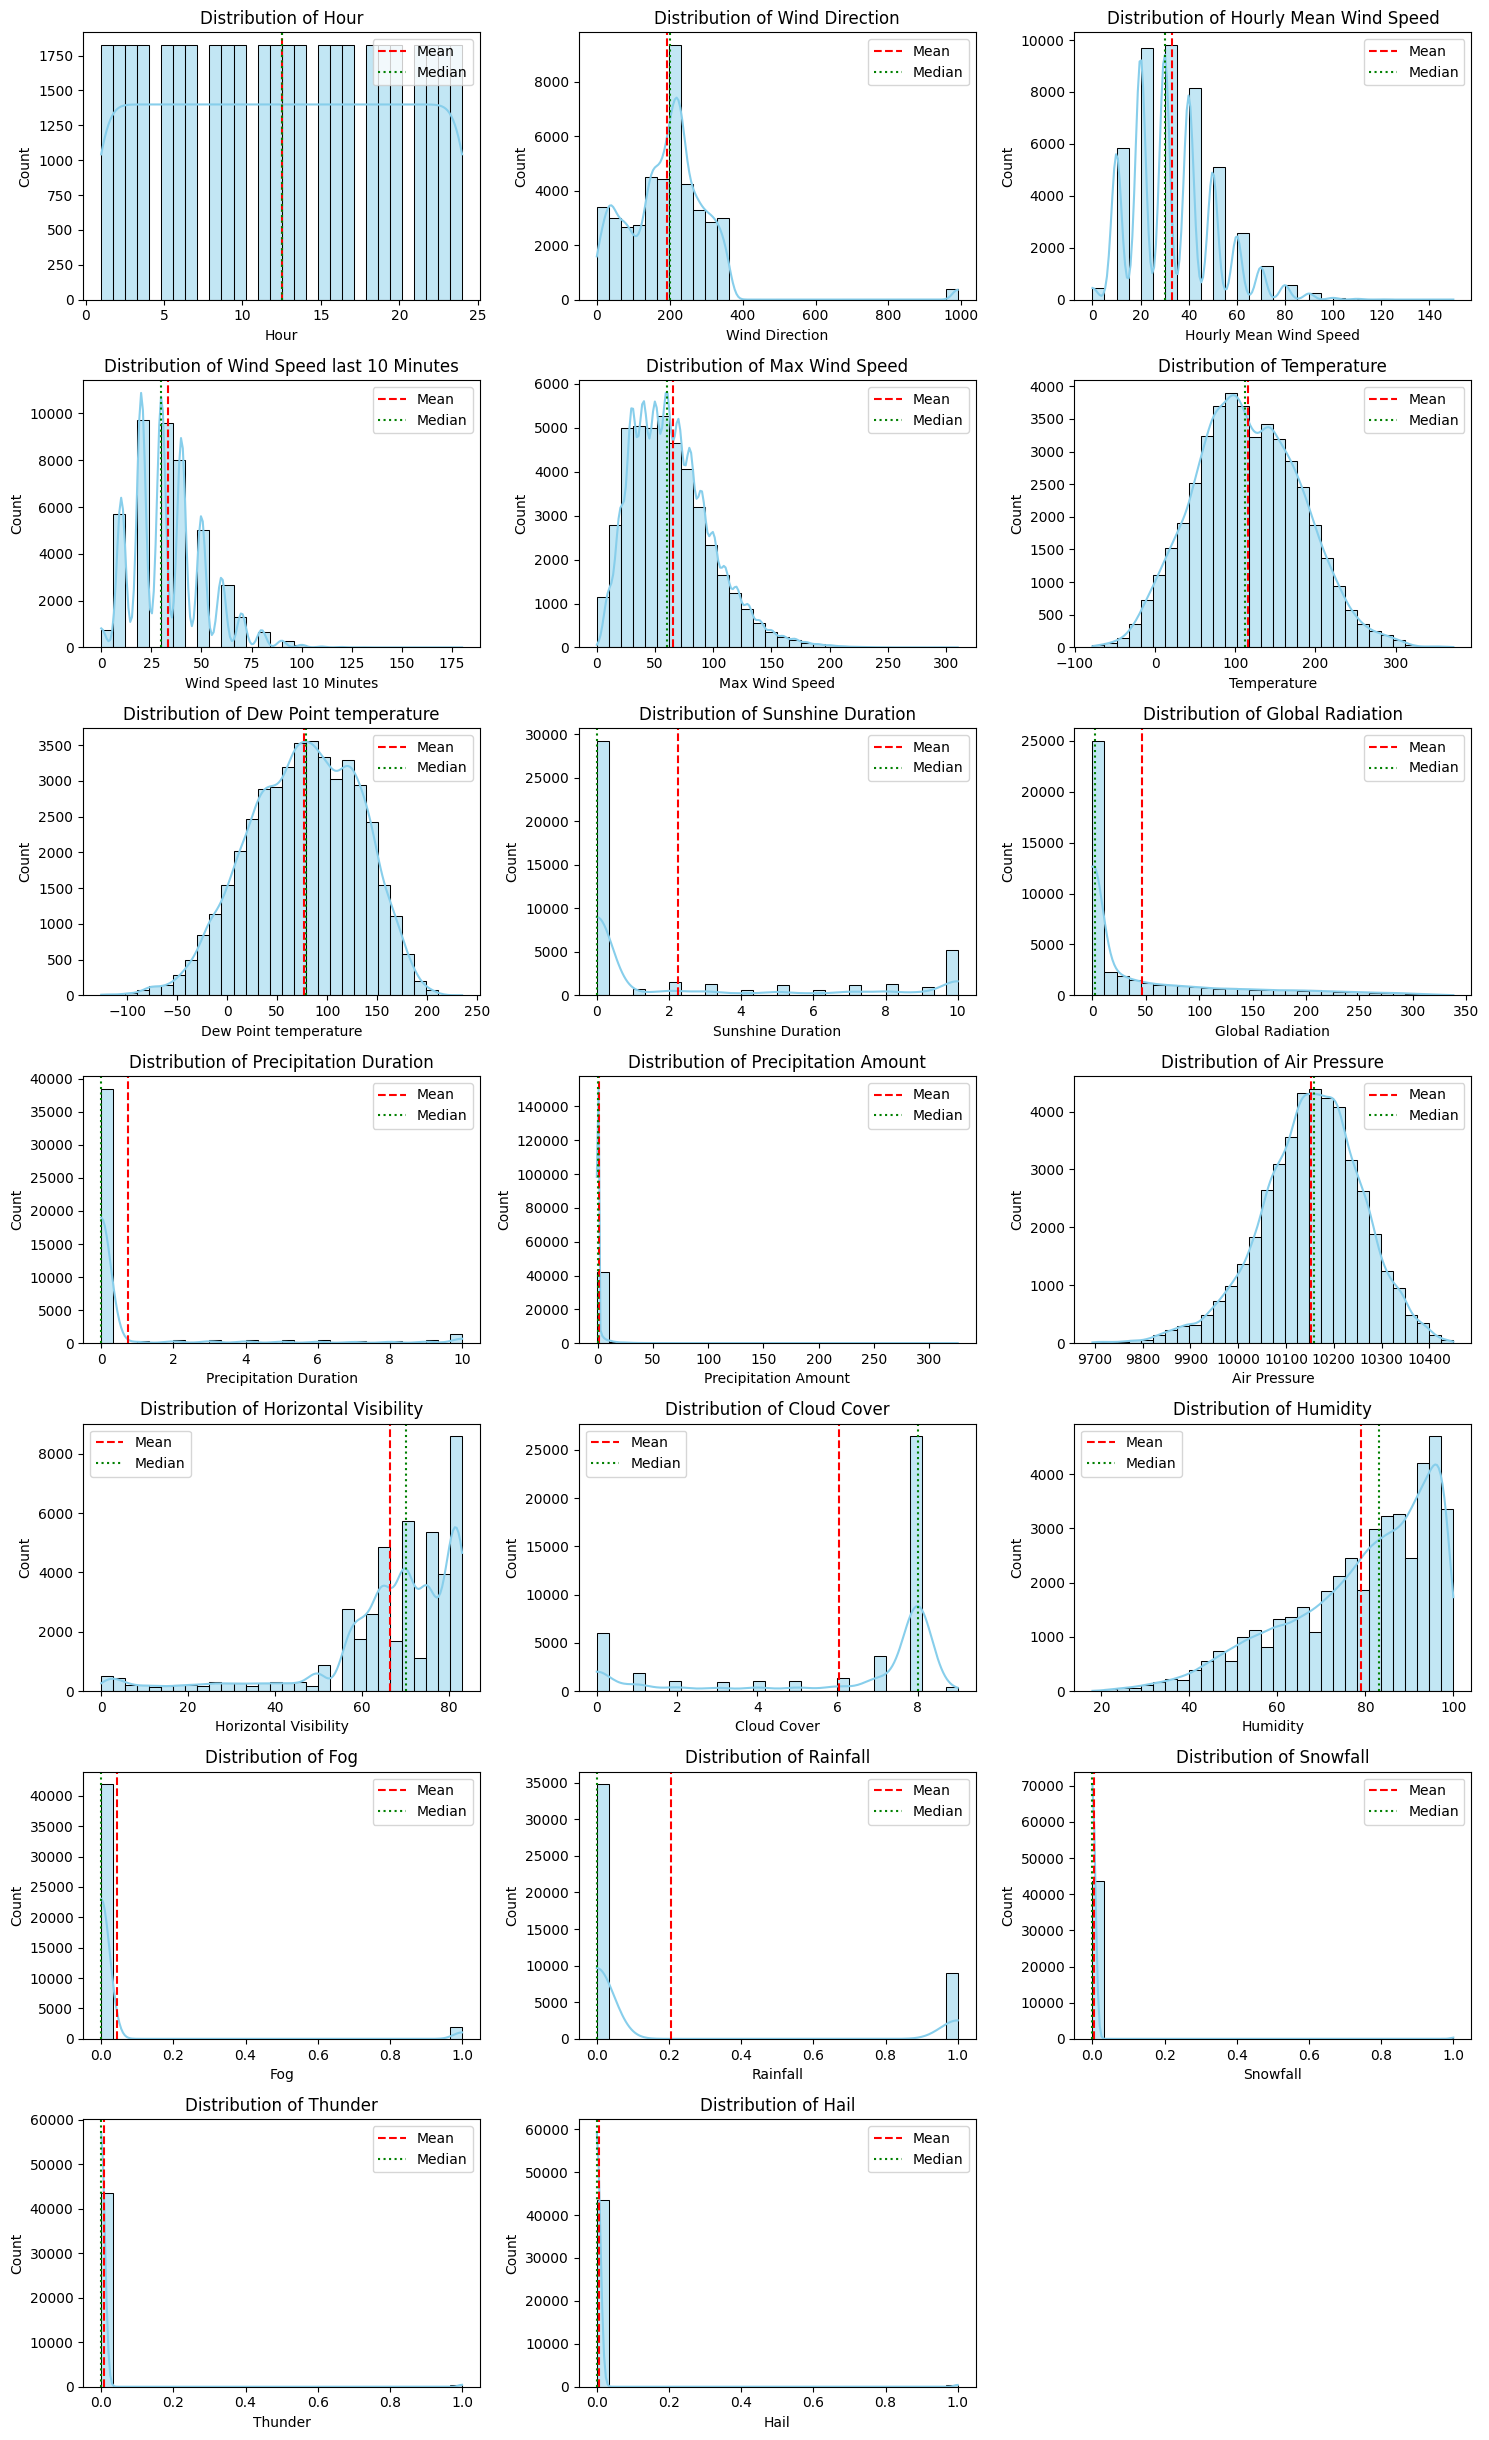

In [12]:
#histogram: for distribution and central tendency (mean, median)
n = len(num_cols)
n_cols = 3
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    data = weather[col].dropna()
    sns.histplot(data, bins=30, kde=True, ax=ax, color="skyblue")
    ax.axvline(data.mean(), color="red", linestyle="--", label="Mean")
    ax.axvline(data.median(), color="green", linestyle=":", label="Median")
    ax.set_title(f"Distribution of {col}")
    ax.set_ylabel("Count")
    ax.legend()

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### Preprocessing Weather: Bivariate

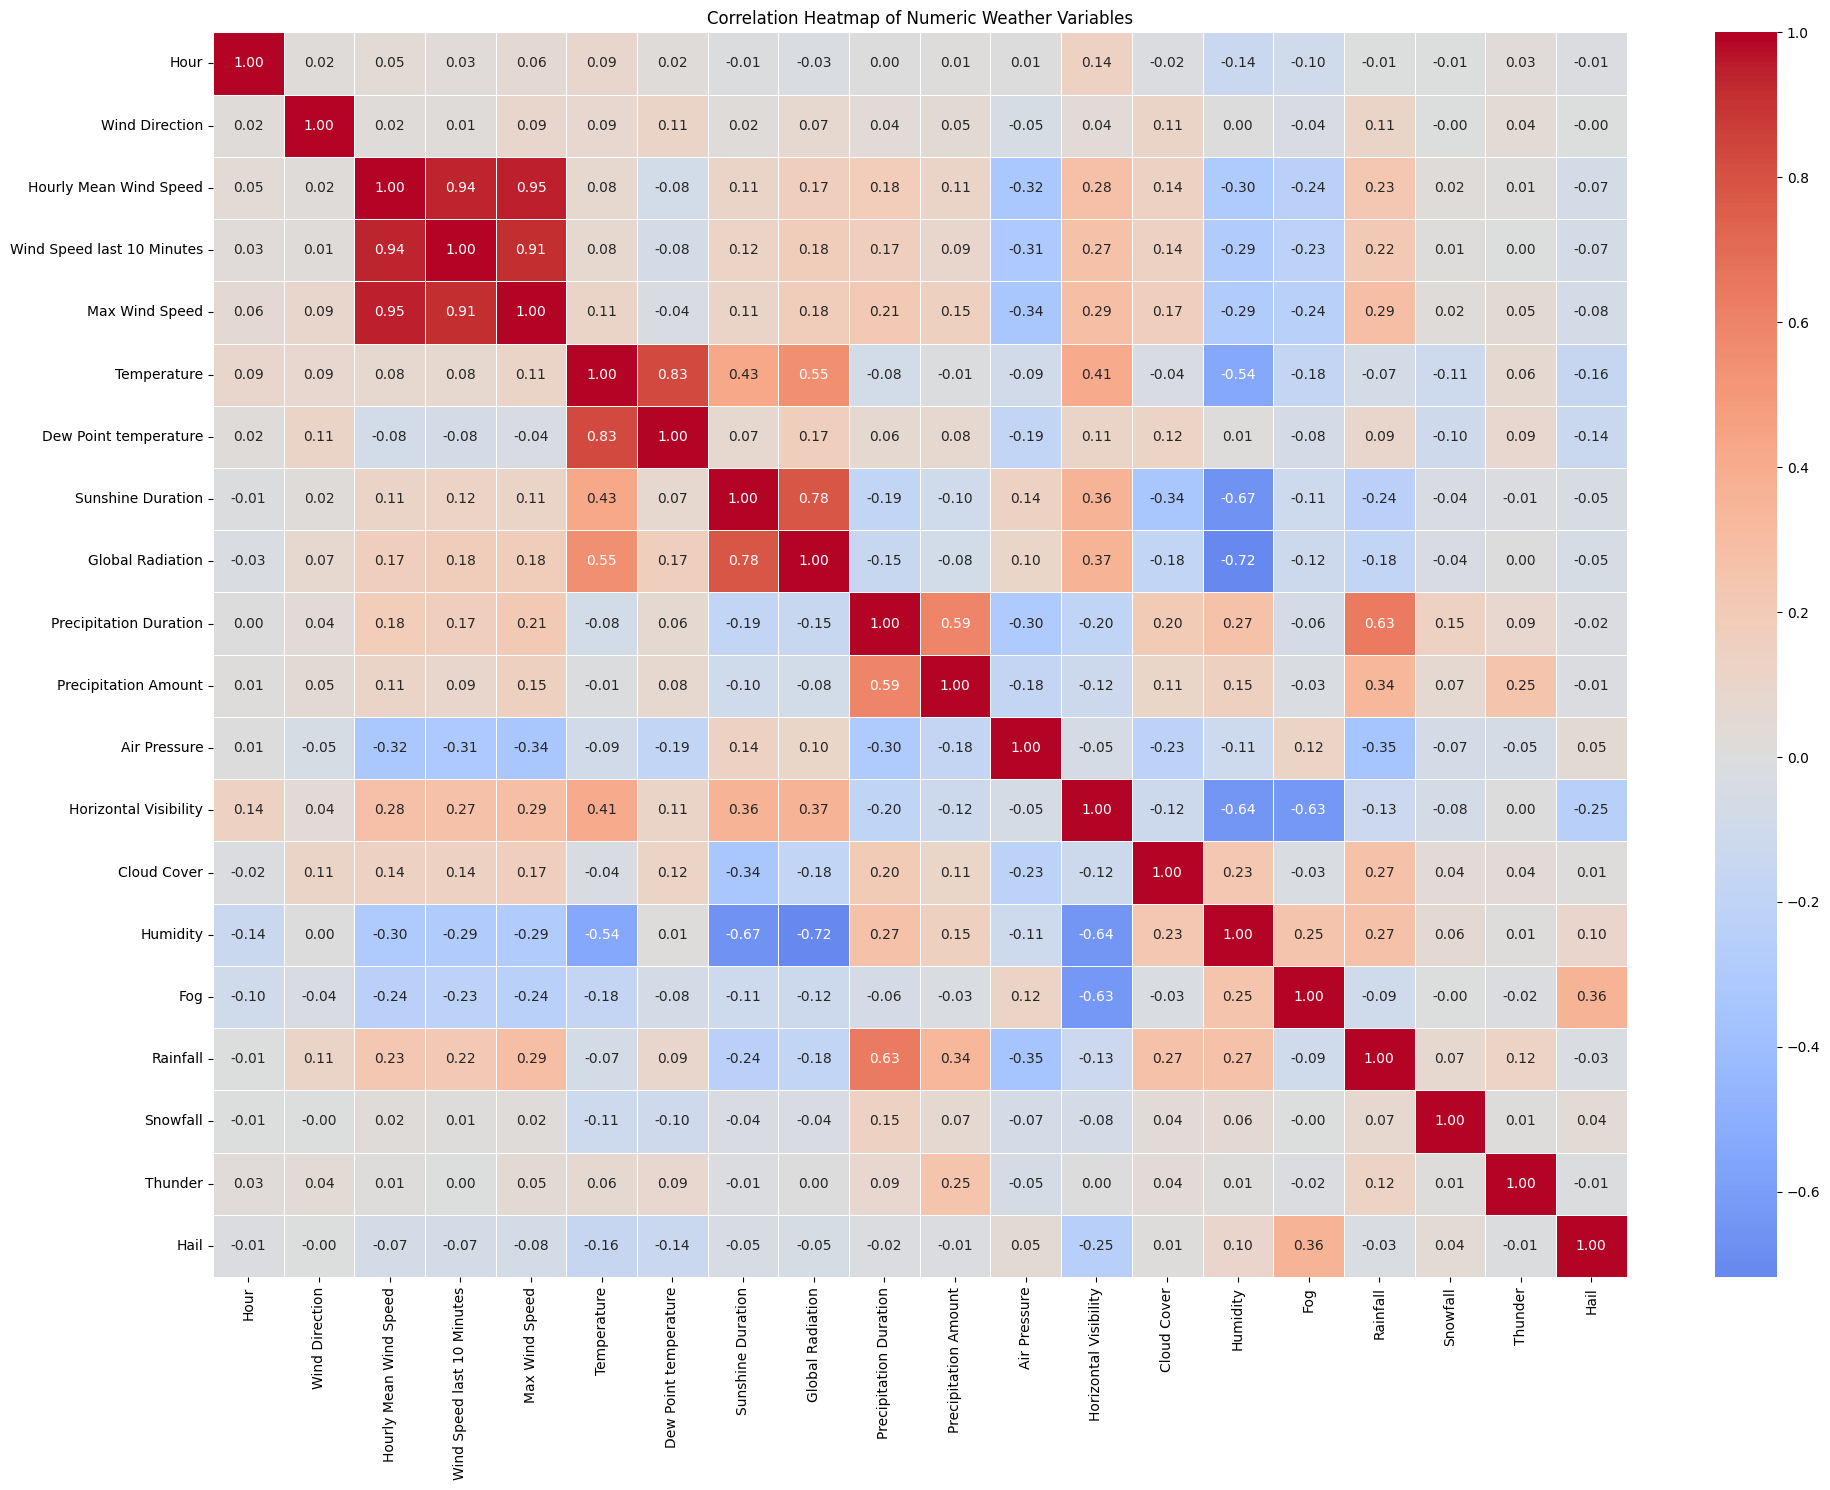

In [13]:
#heatmap: for correlation between numeric variables
corr = weather[num_cols].corr()

plt.figure(figsize=(20, 15))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5, annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Numeric Weather Variables")
plt.tight_layout()
plt.show()

In [14]:
#check the top 10 most correlated pairs of numeric variables
corr_abs = weather[num_cols].corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

top_pairs = upper.stack().sort_values(ascending=False).head(10)
print(top_pairs)

Hourly Mean Wind Speed      Max Wind Speed                0.946481
                            Wind Speed last 10 Minutes    0.939562
Wind Speed last 10 Minutes  Max Wind Speed                0.913648
Temperature                 Dew Point temperature         0.831258
Sunshine Duration           Global Radiation              0.782836
Global Radiation            Humidity                      0.717492
Sunshine Duration           Humidity                      0.666060
Horizontal Visibility       Humidity                      0.638007
                            Fog                           0.634855
Precipitation Duration      Rainfall                      0.632727
dtype: float64


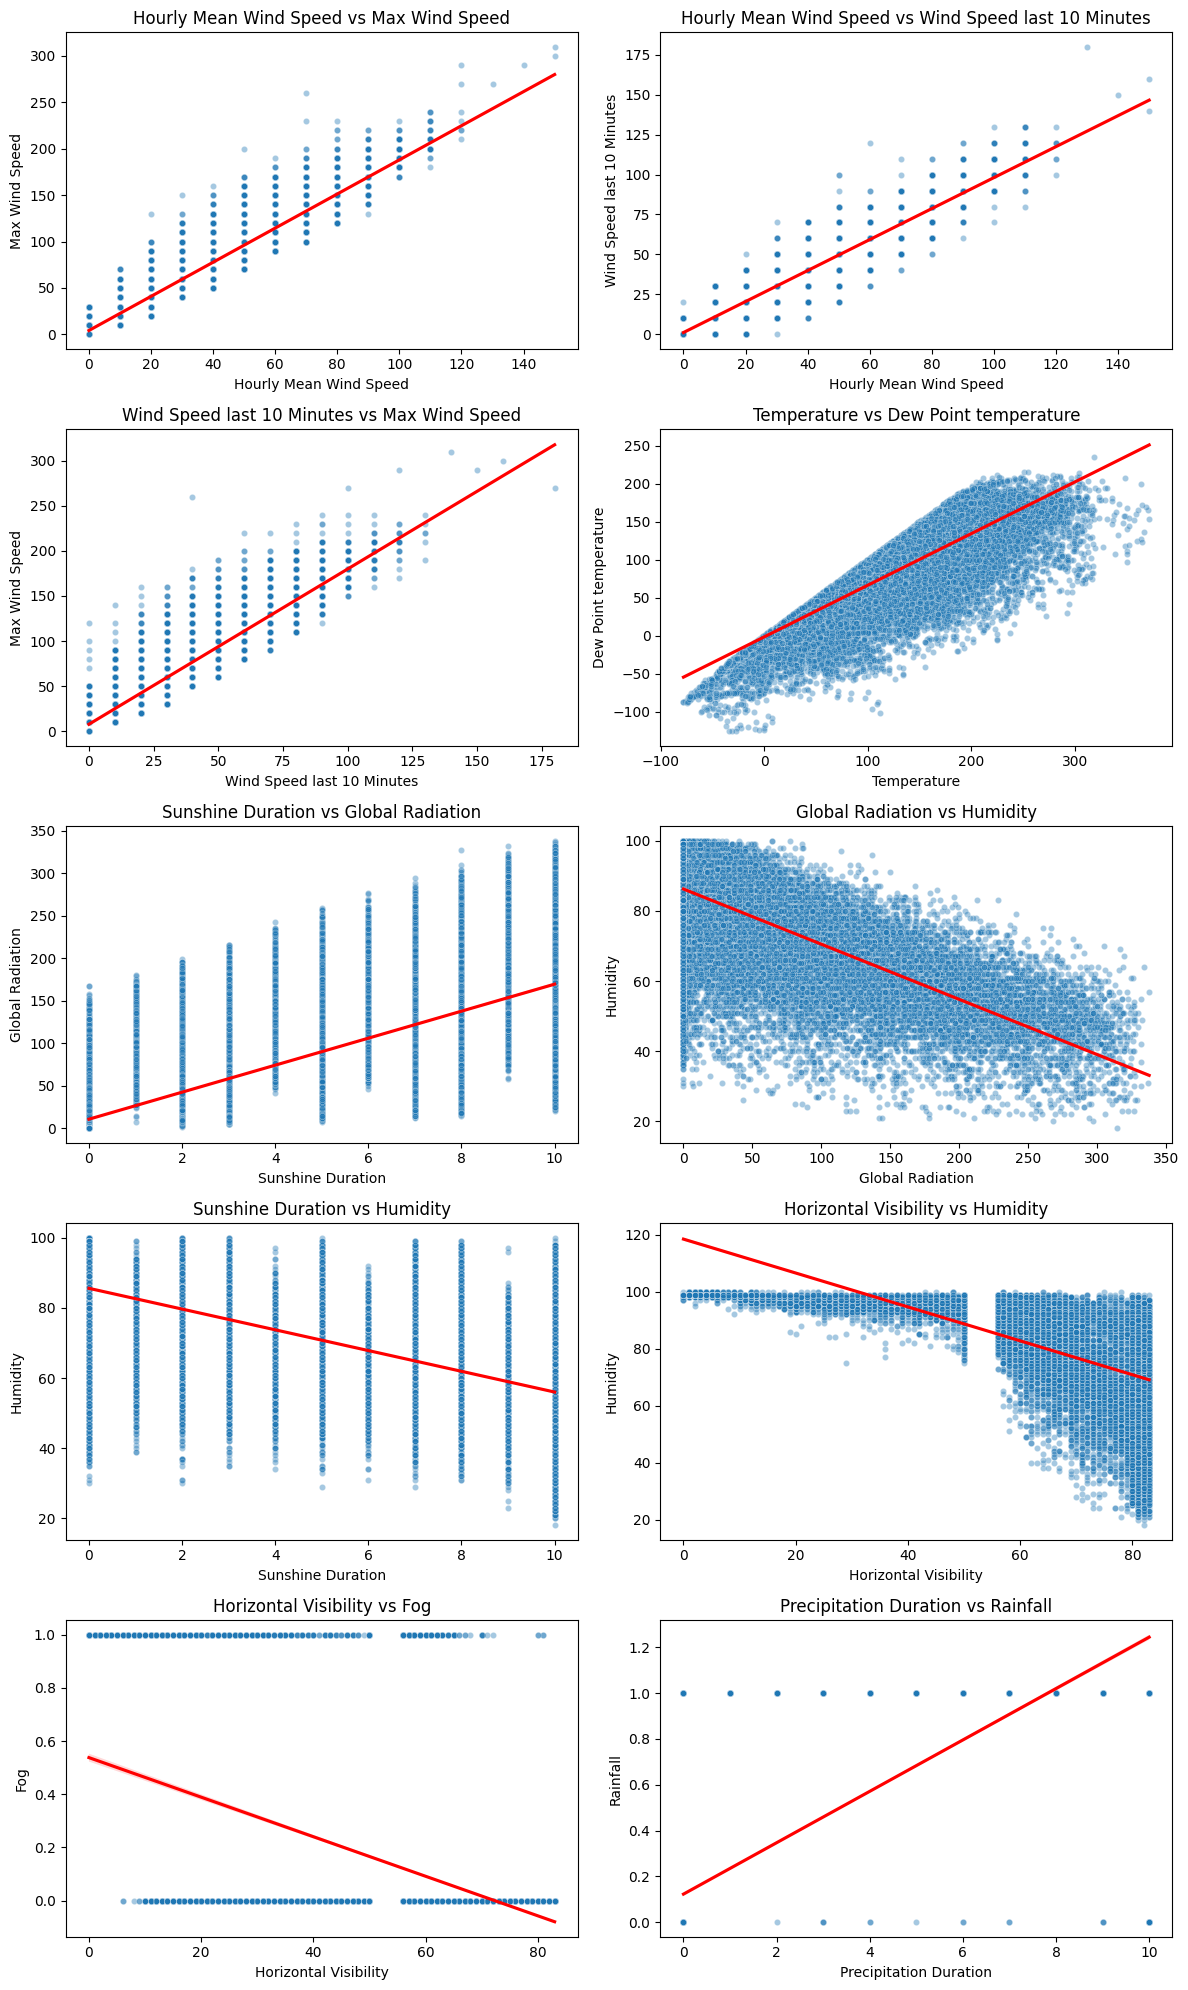

In [15]:
pairs = top_pairs.head(10).index.tolist()

n_pairs = len(pairs)
n_cols = 2
n_rows = math.ceil(n_pairs / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = np.array(axes).flatten()

for ax, (x, y) in zip(axes, pairs):
    sns.scatterplot(data=weather, x=x, y=y, alpha=0.4, s=20, ax=ax)
    sns.regplot(data=weather, x=x, y=y, scatter=False, color="red", ax=ax)
    ax.set_title(f"{x} vs {y}")

for ax in axes[n_pairs:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# EDA: Services

## Load in Data and quick Analysis

In [16]:
#Load in dataset services 2019-2022 (3m8s)
serv19 = pd.read_csv("I:/Datasets Thesis/Train Services 2019-2025/clean/services_clean_2019.csv")
serv22 = pd.read_csv("I:/Datasets Thesis/Train Services 2019-2025/clean/services_clean_2022.csv")
serv23 = pd.read_csv("I:/Datasets Thesis/Train Services 2019-2025/clean/services_clean_2023.csv")
serv24 = pd.read_csv("I:/Datasets Thesis/Train Services 2019-2025/clean/services_clean_2024.csv")
serv25 = pd.read_csv("I:/Datasets Thesis/Train Services 2019-2025/clean/services_clean_2025.csv")


In [17]:
#Concatenate dataset services as one (2m45s) 

df_train = pd.concat([serv19, serv22, serv23, serv24, serv25], ignore_index= True)
serv_col_names = df_train.columns
print( f" The column names of services are: {serv_col_names}" )

rows, columns = df_train.shape
print( f"df_train has Rows: {rows}, Columns: {columns}" ) #Rows: 38571, Columns: 14


 The column names of services are: Index(['Service:RDT-ID', 'Service:Date', 'Service:Type', 'Service:Company',
       'Service:Train number', 'Service:Completely cancelled',
       'Service:Partly cancelled', 'Service:Maximum delay', 'Stop:RDT-ID',
       'Stop:Station code', 'Stop:Station name', 'Stop:Arrival time',
       'Stop:Arrival delay', 'Stop:Arrival cancelled', 'Stop:Departure time',
       'Stop:Departure delay', 'Stop:Departure cancelled',
       'Stop:Platform change', 'Stop:Planned platform',
       'Stop:Actual platform'],
      dtype='str')
df_train has Rows: 69117795, Columns: 20


In [18]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 69117795 entries, 0 to 69117794
Data columns (total 20 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   Service:RDT-ID                int64  
 1   Service:Date                  str    
 2   Service:Type                  str    
 3   Service:Company               str    
 4   Service:Train number          int64  
 5   Service:Completely cancelled  bool   
 6   Service:Partly cancelled      bool   
 7   Service:Maximum delay         int64  
 8   Stop:RDT-ID                   int64  
 9   Stop:Station code             str    
 10  Stop:Station name             str    
 11  Stop:Arrival time             str    
 12  Stop:Arrival delay            float64
 13  Stop:Arrival cancelled        object 
 14  Stop:Departure time           str    
 15  Stop:Departure delay          float64
 16  Stop:Departure cancelled      object 
 17  Stop:Platform change          bool   
 18  Stop:Planned platform         s

In [19]:
# Check memory usage before conversion
print("Memory usage before conversion:")
print(df_train.memory_usage().sum())

# Convert to more memory-efficient datatypes
df_train[["Service:RDT-ID", "Service:Train number", "Service:Maximum delay", "Stop:RDT-ID"]] = df_train[["Service:RDT-ID", "Service:Train number", "Service:Maximum delay", "Stop:RDT-ID"]].apply(pd.to_numeric, downcast='integer').astype('int32')
df_train[["Stop:Arrival delay", "Stop:Departure delay"]] = df_train[["Stop:Arrival delay", "Stop:Departure delay"]].apply(pd.to_numeric, downcast='float').astype('float32')

print("Memory usage after conversion:")
print(df_train.memory_usage().sum())

Memory usage before conversion:
9607373637
Memory usage after conversion:
7948546557


In [20]:
df_train["Service:Company"].value_counts()

Service:Company
NS    69117795
Name: count, dtype: int64

In [21]:
df_train["Service:Type"].value_counts()

Service:Type
Sprinter            45410916
Intercity           22762237
Intercity direct      893074
Extra trein            51568
Name: count, dtype: int64

## Preprocessing Services: Missing Values

In [22]:
total_serv19 = df_train.isnull().sum().sort_values(ascending=False)
percent_serv19 = (df_train.isnull().sum()/df_train.isnull().count()).sort_values(ascending=False)
missing_data_serv19 = pd.concat([total_serv19, percent_serv19], axis=1, keys=['Total', 'Percent'])
missing_data_serv19

,Total,Percent
Stop:Departure cancelled,6646562,0.096163
Stop:Departure delay,6646562,0.096163
Stop:Departure time,6646562,0.096163
Stop:Arrival time,6644559,0.096134
Stop:Arrival cancelled,6644559,0.096134
Stop:Arrival delay,6644559,0.096134
Stop:Planned platform,3398015,0.049163
Stop:Actual platform,3398015,0.049163
Service:Company,0,0.000000
Service:Type,0,0.000000


In [23]:
# Rows where departure cancellation is missing
departure_null = df_train[df_train["Stop:Departure cancelled"].isna()].copy()

# Missingness flags
departure_null["departure_time_isna"] = departure_null["Stop:Departure time"].isna()
departure_null["departure_delay_isna"] = departure_null["Stop:Departure delay"].isna()

# Overview table
summary_departure_null = pd.crosstab(
    departure_null["departure_time_isna"],
    departure_null["departure_delay_isna"],
    margins=True
)
display(summary_departure_null)

# Explicit rule check: both must be NaN
rule_holds = (departure_null["departure_time_isna"] & departure_null["departure_delay_isna"]).all()
print("Rule holds:", rule_holds)

# Show counterexamples, if any
violations = departure_null[~(departure_null["departure_time_isna"] & departure_null["departure_delay_isna"])]
print("Violations:", len(violations))
if len(violations) > 0:
    display(violations.head(20))

departure_delay_isna,True,All
departure_time_isna,,
True,6646562,6646562
All,6646562,6646562


Rule holds: True
Violations: 0


In [24]:
# Rows where arrival cancellation is missing
arrival_null = df_train[df_train["Stop:Arrival cancelled"].isna()].copy()

# Missingness flags
arrival_null["arrival_time_isna"] = arrival_null["Stop:Arrival time"].isna()
arrival_null["arrival_delay_isna"] = arrival_null["Stop:Arrival delay"].isna()

# Overview table
summary_arrival_null = pd.crosstab(
    arrival_null["arrival_time_isna"],
    arrival_null["arrival_delay_isna"],
    margins=True
)
display(summary_arrival_null)

# Explicit rule check: both must be NaN
rule_holds = (arrival_null["arrival_time_isna"] & arrival_null["arrival_delay_isna"]).all()
print("Rule holds:", rule_holds)

# Show counterexamples, if any
violations = arrival_null[~(arrival_null["arrival_time_isna"] & arrival_null["arrival_delay_isna"])]
print("Violations:", len(violations))
if len(violations) > 0:
    display(violations.head(20))

arrival_delay_isna,True,All
arrival_time_isna,,
True,6644559,6644559
All,6644559,6644559


Rule holds: True
Violations: 0


In [25]:
# Check rows where planned platform is NaN or False
planned_col = df_train["Stop:Planned platform"]
actual_col = df_train["Stop:Actual platform"]

planned_is_false = planned_col.eq(False) | planned_col.astype(str).str.strip().str.lower().eq("false")
planned_is_na_or_false = planned_col.isna() | planned_is_false

planned_platform_null = df_train.loc[planned_is_na_or_false, ["Stop:Planned platform", "Stop:Actual platform"]].copy()

# Create boolean flags for missingness (without overwriting original columns)
planned_platform_null["planned_is_na"] = planned_platform_null["Stop:Planned platform"].isna()
planned_platform_null["actual_is_na"] = planned_platform_null["Stop:Actual platform"].isna()

# Summary: among rows where planned is NaN or False, is actual also NaN?
summary_planned_platform_null = pd.crosstab(
    planned_platform_null["planned_is_na"],
    planned_platform_null["actual_is_na"],
    margins=True
)

display(summary_planned_platform_null)

# Rows that do NOT satisfy "both planned and actual are NaN"
violations = planned_platform_null[
    ~(planned_platform_null["planned_is_na"] & planned_platform_null["actual_is_na"])
]

print(f"Rows checked (planned NaN or False): {len(planned_platform_null)}")
print(f"Rows where both planned and actual are NaN: {len(planned_platform_null) - len(violations)}")
print(f"Violations: {len(violations)}")

if len(violations) > 0:
    display(violations.head(20))

actual_is_na,True,All
planned_is_na,,
True,3398015,3398015
All,3398015,3398015


Rows checked (planned NaN or False): 3398015
Rows where both planned and actual are NaN: 3398015
Violations: 0


In [26]:
arr_cancel_na = df_train["Stop:Arrival cancelled"].isna()
dep_cancel_na = df_train["Stop:Departure cancelled"].isna()

# Explicit non-cancelled events
arr_valid = df_train["Stop:Arrival cancelled"].eq(False)
dep_valid = df_train["Stop:Departure cancelled"].eq(False)

# Start station:
# Arrival cancelled = NaN AND Departure cancelled = False
start_station_mask = arr_cancel_na & dep_valid

# End station:
# Departure cancelled = NaN AND Arrival cancelled = False
end_station_mask = dep_cancel_na & arr_valid

# Total missing values
total_arr_missing = arr_cancel_na.sum()
total_dep_missing = dep_cancel_na.sum()

# Counts matching assumption
start_count = start_station_mask.sum()
end_count = end_station_mask.sum()

# Percentages
start_pct = (start_count / total_arr_missing * 100) if total_arr_missing > 0 else 0
end_pct = (end_count / total_dep_missing * 100) if total_dep_missing > 0 else 0

# Summary table
summary = pd.DataFrame({
    "Missing values": [total_arr_missing, total_dep_missing],
    "Matches assumption": [start_count, end_count],
    "Percentage explained": [start_pct, end_pct]
}, index=[
    "Arrival cancelled NaN = Start stations",
    "Departure cancelled NaN = End stations"
])

display(summary)

# Check impossible overlap
print("Overlap between start and end stations:", 
      (start_station_mask & end_station_mask).sum())

,Missing values,Matches assumption,Percentage explained
Arrival cancelled NaN = Start stations,6644559,6302550,94.852796
Departure cancelled NaN = End stations,6646562,6299267,94.774817


Overlap between start and end stations: 0


In [27]:
# Create a subset of the DataFrame with only the cancellation-related columns
cancelled_columns = df_train[[
    "Stop:Arrival cancelled",
    "Stop:Departure cancelled",
    "Service:Partly cancelled",
    "Service:Completely cancelled"
 ]].copy()

# Group by the cancellation columns and count occurrences
cancelled_columns.groupby([
    "Stop:Arrival cancelled",  
    "Stop:Departure cancelled", 
    "Service:Partly cancelled", 
    "Service:Completely cancelled",], 
    dropna=False).size().reset_index(name='count')

,Stop:Arrival cancelled,Stop:Departure cancelled,Service:Partly cancelled,Service:Completely cancelled,count
0,NaN,False,False,False,6081180
1,NaN,False,False,True,3103
2,NaN,False,True,False,217892
3,NaN,False,True,True,375
4,NaN,NaN,False,False,4764
5,NaN,NaN,False,True,37
6,NaN,NaN,True,False,353
7,NaN,NaN,True,True,112
8,NaN,True,False,True,3
9,NaN,True,True,False,195887


In [28]:
# Create is_cancelled directly in this cell
arr = df_train["Stop:Arrival cancelled"]
dep = df_train["Stop:Departure cancelled"]
complete = df_train["Service:Completely cancelled"] if "Service:Completely cancelled" in df_train.columns else pd.Series(False, index=df_train.index)

df_train["is_cancelled"] = 1
not_cancelled_mask = (
    (complete == False) &
    (
        (arr.isna() & (dep == False)) |
        ((arr == False) & dep.isna()) |
        ((arr == False) & (dep == False))
    )
)
df_train.loc[not_cancelled_mask, "is_cancelled"] = 0

cancelled_columns["is_cancelled"] = df_train["is_cancelled"]

cancelled_columns.groupby([
    "Stop:Arrival cancelled", 
    "Stop:Departure cancelled", 
    "Service:Partly cancelled", 
    "Service:Completely cancelled",
    "is_cancelled"
], dropna=False).size().reset_index(name='count')

,Stop:Arrival cancelled,Stop:Departure cancelled,Service:Partly cancelled,Service:Completely cancelled,is_cancelled,count
0,NaN,False,False,False,0,6081180
1,NaN,False,False,True,1,3103
2,NaN,False,True,False,0,217892
3,NaN,False,True,True,1,375
4,NaN,NaN,False,False,1,4764
5,NaN,NaN,False,True,1,37
6,NaN,NaN,True,False,1,353
7,NaN,NaN,True,True,1,112
8,NaN,True,False,True,1,3
9,NaN,True,True,False,1,195887


## Data Visualization

Cancellation rate by year (%)


,year,cancel_rate_percentage
0,2019,3.08
1,2022,7.60
2,2023,5.88
3,2024,5.23
4,2025,6.96


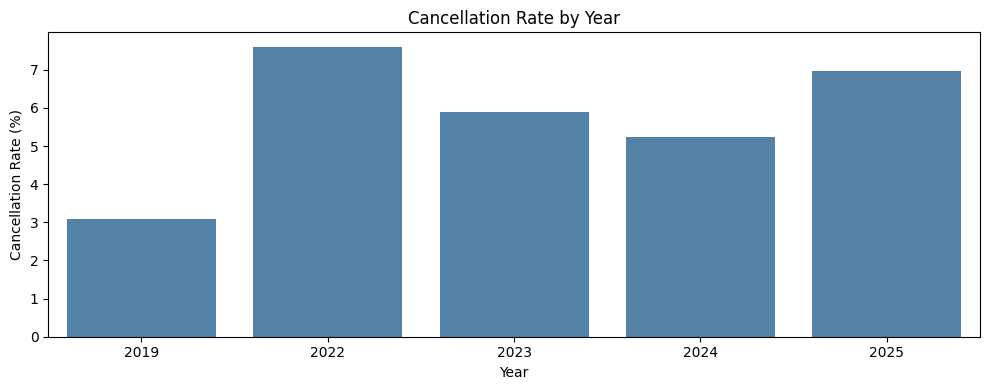


Cancellation rate by month (%)


,month,cancel_rate_percentage
0,1,5.22
1,2,5.41
2,3,4.54
3,4,5.33
4,5,5.25
5,6,7.51
6,7,5.49
7,8,6.02
8,9,6.92
9,10,5.67


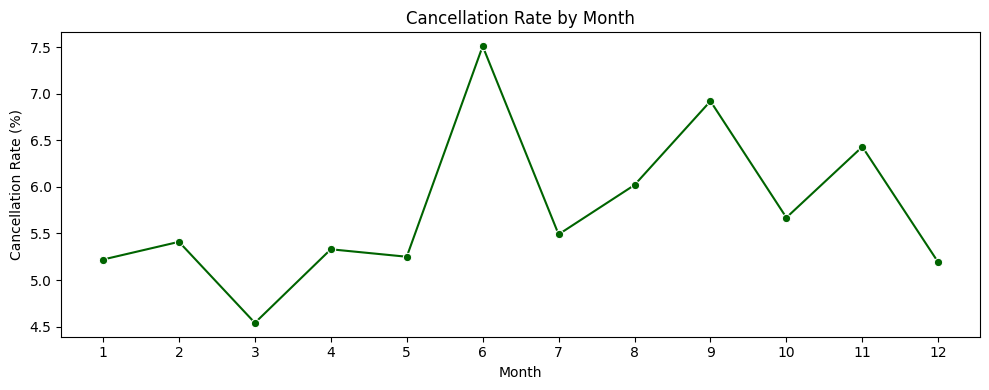


Cancellation rate by day of week (%)


,weekday,cancel_rate_percentage
1,Monday,5.82
5,Tuesday,6.83
6,Wednesday,5.87
4,Thursday,5.72
0,Friday,6.09
2,Saturday,4.93
3,Sunday,4.47


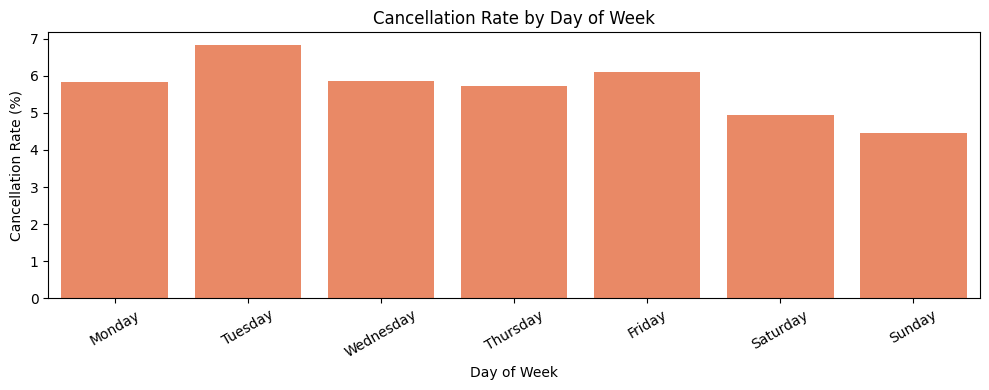


Cancellation rate by hour (%)


,hour,cancel_rate_percentage
0,0.0,3.09
1,1.0,5.58
2,2.0,5.41
3,3.0,4.00
4,4.0,4.45
5,5.0,4.97
6,6.0,5.53
7,7.0,5.83
8,8.0,5.93
9,9.0,5.93


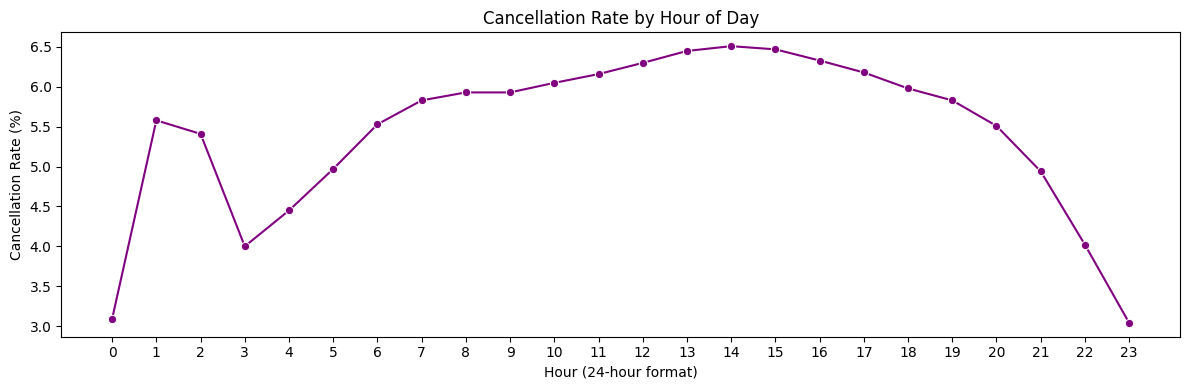

In [29]:
# Cancellation Rate Analysis by Year, Month, Day of Week, and Hour
df_time = df_train.copy()
df_time["Service:Date"] = pd.to_datetime(df_time["Service:Date"], errors="coerce")
df_time = df_time.dropna(subset=["Service:Date"])

df_time["year"] = df_time["Service:Date"].dt.year
df_time["month"] = df_time["Service:Date"].dt.month
df_time["weekday"] = df_time["Service:Date"].dt.day_name()

# Extract hour from departure time
if "Stop:Departure time" in df_time.columns:
    dep_time_utc = pd.to_datetime(df_time["Stop:Departure time"], errors="coerce", utc=True)
    df_time["hour"] = dep_time_utc.dt.hour
else:
    df_time["hour"] = pd.NA

# Cancellation rate by year
rate_year = df_time.groupby("year")["is_cancelled"].mean().mul(100).round(2).reset_index(name="cancel_rate_percentage")
print("Cancellation rate by year (%)")
display(rate_year)

plt.figure(figsize=(10, 4))
sns.barplot(data=rate_year, x="year", y="cancel_rate_percentage", color="steelblue")
plt.title("Cancellation Rate by Year")
plt.ylabel("Cancellation Rate (%)")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

# Cancellation rate by month
rate_month = df_time.groupby("month")["is_cancelled"].mean().mul(100).round(2).reset_index(name="cancel_rate_percentage").sort_values("month")
print("\nCancellation rate by month (%)")
display(rate_month)

plt.figure(figsize=(10, 4))
sns.lineplot(data=rate_month, x="month", y="cancel_rate_percentage", marker="o", color="darkgreen")
plt.title("Cancellation Rate by Month")
plt.ylabel("Cancellation Rate (%)")
plt.xlabel("Month")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

# Cancellation rate by day of week
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
rate_weekday = df_time.groupby("weekday")["is_cancelled"].mean().mul(100).round(2).reset_index(name="cancel_rate_percentage")
rate_weekday["weekday"] = pd.Categorical(rate_weekday["weekday"], categories=weekday_order, ordered=True)
rate_weekday = rate_weekday.sort_values("weekday")
print("\nCancellation rate by day of week (%)")
display(rate_weekday)

plt.figure(figsize=(10, 4))
sns.barplot(data=rate_weekday, x="weekday", y="cancel_rate_percentage", color="coral")
plt.title("Cancellation Rate by Day of Week")
plt.ylabel("Cancellation Rate (%)")
plt.xlabel("Day of Week")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Cancellation rate by hour
hour_data = df_time.dropna(subset=["hour"])
if len(hour_data) > 0:
    rate_hour = hour_data.groupby("hour")["is_cancelled"].mean().mul(100).round(2).reset_index(name="cancel_rate_percentage")
    print("\nCancellation rate by hour (%)")
    display(rate_hour)

    plt.figure(figsize=(12, 4))
    sns.lineplot(data=rate_hour, x="hour", y="cancel_rate_percentage", marker="o", color="purple")
    plt.title("Cancellation Rate by Hour of Day")
    plt.ylabel("Cancellation Rate (%)")
    plt.xlabel("Hour (24-hour format)")
    plt.xticks(range(0, 24))
    plt.tight_layout()
    plt.show()

Top 10 stations by number of cancellations


,Stop:Station name,cancel_count,total_stops,cancel_rate_pct
254,Utrecht Centraal,128509,2218567,5.79
23,Amsterdam Centraal,127323,1961793,6.49
224,Rotterdam Centraal,108308,1259264,8.60
236,Schiphol Airport,98770,1359173,7.27
29,Amsterdam Sloterdijk,87683,1464348,5.99
173,Leiden Centraal,79835,1071413,7.45
0,'s-Hertogenbosch,75856,890858,8.51
80,Den Haag Centraal,70056,1185805,5.91
106,Eindhoven Centraal,58739,644115,9.12
30,Amsterdam Zuid,58485,769364,7.60


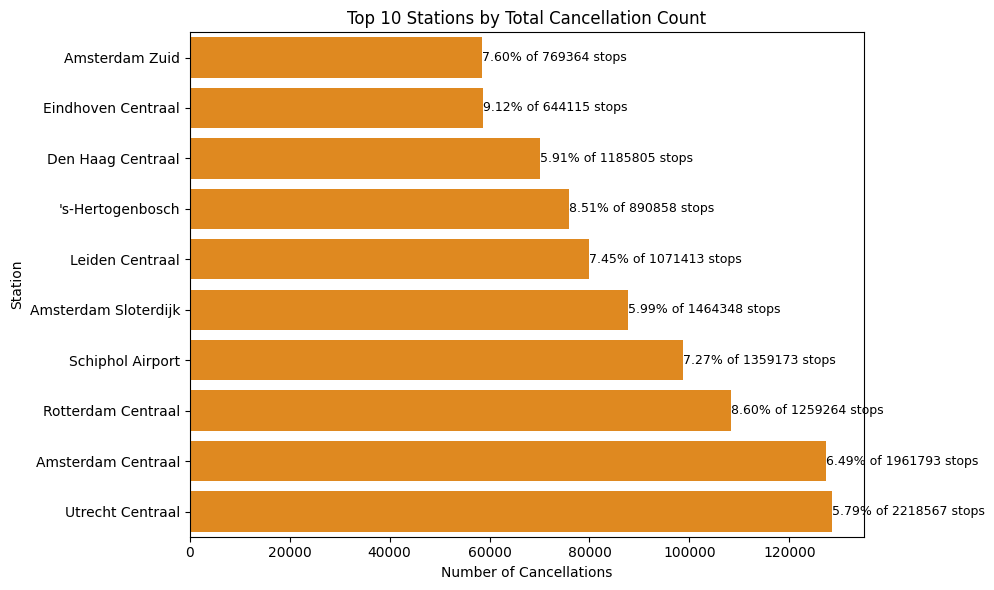

In [30]:

# Build a summary with cancellation at station level, sorted by total cancellations

# Calculate cancellation count and total stops per station
rate_station = (
    df_time.groupby("Stop:Station name")["is_cancelled"]
    .agg(cancel_count="sum", total_stops="count")
    .assign(cancel_rate_pct=lambda x: ((x["cancel_count"] / x["total_stops"]) * 100).round(2))
    .reset_index()
    .sort_values("cancel_count", ascending=False)
)

# Display the top 10 stations by cancellation count
print("Top 10 stations by number of cancellations")
display(rate_station.head(10))

top10 = rate_station.head(10).sort_values("cancel_count", ascending=True)  # ascending for horizontal bar readability

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top10, y="Stop:Station name", x="cancel_count", color="darkorange", ax=ax)

# Add rate label at the end of each bar
for i, (_, row) in enumerate(top10.iterrows()):
    ax.text(
        row["cancel_count"] + 10,
        i,
        f"{row['cancel_rate_pct']:.2f}% of {int(row['total_stops'])} stops",
        va="center",
        fontsize=9
    )

ax.set_title("Top 10 Stations by Total Cancellation Count")
ax.set_xlabel("Number of Cancellations")
ax.set_ylabel("Station")
plt.tight_layout()
plt.show()


Cancellation rate by service type (%)


,Service:Type,cancel_rate_pct
2,Intercity direct,11.981090
1,Intercity,8.250121
0,Extra trein,5.600372
3,Sprinter,4.370592


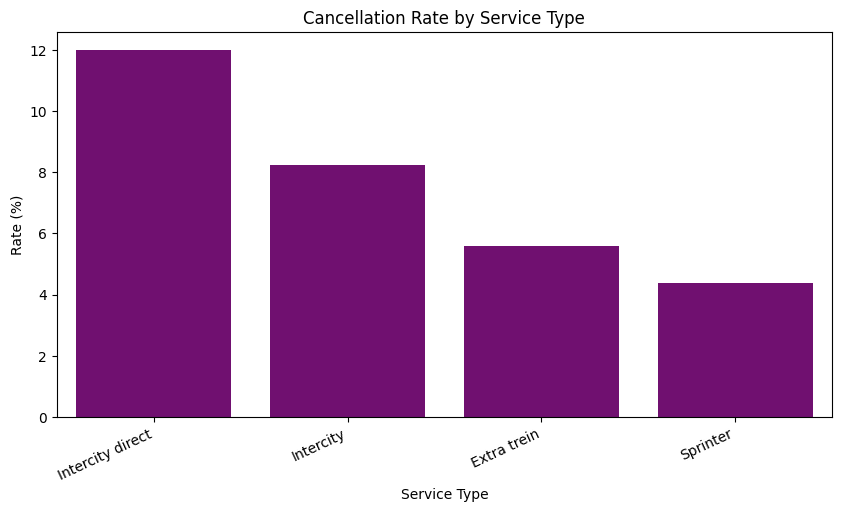

In [31]:
# Cancellation rate by service type
rate_type = (
df_time.groupby("Service:Type")["is_cancelled"]
.mean()
.mul(100)
.reset_index(name="cancel_rate_pct")
.sort_values("cancel_rate_pct", ascending=False)
)

print("Cancellation rate by service type (%)")
display(rate_type)

plt.figure(figsize=(10, 5))
sns.barplot(data=rate_type, x="Service:Type", y="cancel_rate_pct", color="purple")
plt.title("Cancellation Rate by Service Type")
plt.ylabel("Rate (%)")
plt.xlabel("Service Type")
plt.xticks(rotation=25, ha="right")
plt.show()

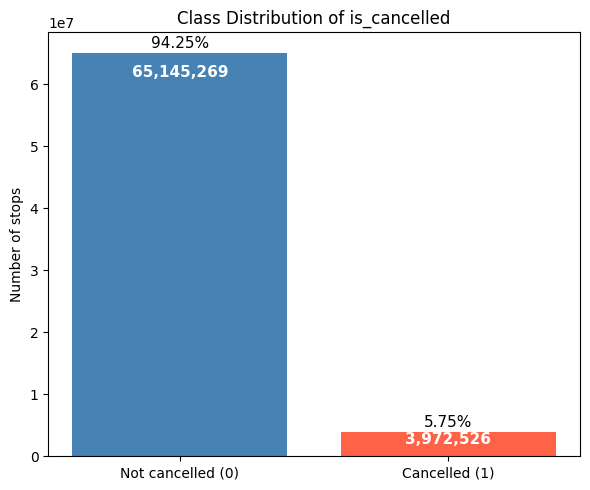

In [32]:
counts = df_time["is_cancelled"].value_counts().sort_index()
total  = len(df_time)

num_not_cancelled = counts.get(0, 0)
num_cancelled     = counts.get(1, 0)
pct_cancelled     = num_cancelled / total * 100
imbalance_ratio   = num_not_cancelled / num_cancelled if num_cancelled > 0 else float("inf")

# Bar chart
class_labels = ["Not cancelled (0)", "Cancelled (1)"]
class_counts  = [num_not_cancelled, num_cancelled]
class_pcts    = [round(100 - pct_cancelled, 2), round(pct_cancelled, 2)]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(class_labels, class_counts, color=["steelblue", "tomato"])

for bar, count, pct in zip(bars, class_counts, class_pcts):
    # Show count inside the bar (near top)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 0.97,
        f"{count:,}",
        ha="center", va="top", fontsize=11, color="white", fontweight="bold"
    )
    # Show percentage just above the bar
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.003,
        f"{pct:.2f}%",
        ha="center", va="bottom", fontsize=11
    )

ax.set_title("Class Distribution of is_cancelled")
ax.set_ylabel("Number of stops")
plt.tight_layout()
plt.show()

# Combine Dataset

In [33]:
# Add hour column to df_train using departure time, then arrival time as fallback
dep_time = pd.to_datetime(df_train["Stop:Departure time"], errors="coerce", utc=True)
arr_time = pd.to_datetime(df_train["Stop:Arrival time"], errors="coerce", utc=True)

# Prefer departure hour; if missing, use arrival hour
df_train["Hour"] = dep_time.dt.hour.fillna(arr_time.dt.hour).astype("Int32")

# Remap midnight from 0 to 24 so hour range is 1..24
df_train.loc[df_train["Hour"] == 0, "Hour"] = 24

# Forward-fill any remaining NaN hours (e.g., for rows where both departure and arrival times are missing)
df_train['Hour'] = df_train.groupby('Service:RDT-ID')['Hour'].ffill()

# Encode Hour to cyclical features using sine and cosine transformations
df_train["Hour_sin"] = np.sin(
    2 * np.pi * df_train["Hour"] / 24
)

df_train["Hour_cos"] = np.cos(
    2 * np.pi * df_train["Hour"] / 24
)

In [34]:
df_train = df_train.assign(
    YYYYMMDD=pd.to_datetime(df_train["Service:Date"], errors="coerce").dt.normalize(),
    Hour=pd.to_numeric(df_train["Hour"], errors="coerce").astype("Int64"),
)

comb = df_train.merge(
    weather.rename(columns={"Date": "YYYYMMDD"})
           .assign(
               YYYYMMDD=lambda x: pd.to_datetime(x["YYYYMMDD"], errors="coerce").dt.normalize(),
               Hour=lambda x: pd.to_numeric(x["Hour"], errors="coerce").astype("Int64"),
           )
           .sort_values(["YYYYMMDD", "Hour"])   
           .drop_duplicates(["YYYYMMDD", "Hour"]),
    on=["YYYYMMDD", "Hour"],
    how="left",
    suffixes=("", "_weather"),
)

print(comb.shape)
display(comb.head())

(69117795, 44)


,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,...,Precipitation Amount,Air Pressure,Horizontal Visibility,Cloud Cover,Humidity,Fog,Rainfall,Snowfall,Thunder,Hail
0,738804,2019-01-01,Intercity,NS,1410,False,False,1,6220112,RTD,...,0.0,10309.0,36.0,8.0,89.0,0.0,0.0,0.0,0.0,0.0
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,...,0.0,10309.0,36.0,8.0,89.0,0.0,0.0,0.0,0.0,0.0
2,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,...,0.0,10309.0,36.0,8.0,89.0,0.0,0.0,0.0,0.0,0.0
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,...,0.0,10309.0,36.0,8.0,89.0,0.0,0.0,0.0,0.0,0.0
4,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220128,SHL,...,0.0,10306.0,41.0,8.0,82.0,0.0,0.0,0.0,0.0,0.0


In [35]:
# Ensure temporal columns exist before feature engineering
if "Service:Date" in comb.columns:
    service_date = pd.to_datetime(comb["Service:Date"], errors="coerce")

    if "DayOfWeek" not in comb.columns:
        comb["DayOfWeek"] = service_date.dt.dayofweek.astype("Int8")

    if "Month" not in comb.columns:
        comb["Month"] = service_date.dt.month.astype("Int8")

# Encode day of week as cyclical features
comb["DayOfWeek_sin"] = np.sin(2 * np.pi * comb["DayOfWeek"] / 7).astype("float32")
comb["DayOfWeek_cos"] = np.cos(2 * np.pi * comb["DayOfWeek"] / 7).astype("float32")

# Encode month as cyclical features
comb["Month_sin"] = np.sin(2 * np.pi * comb["Month"] / 12).astype("float32")
comb["Month_cos"] = np.cos(2 * np.pi * comb["Month"] / 12).astype("float32")

# Create a binary feature for weekend (1 if Saturday or Sunday, 0 otherwise)
comb["IsWeekend"] = (comb["DayOfWeek"] >= 5).astype("Int8")

# Create season feature based on month (vectorized)
comb["Season"] = np.select(
    [
        comb["Month"].isin([12, 1, 2]),
        comb["Month"].isin([3, 4, 5]),
        comb["Month"].isin([6, 7, 8])
    ],
    ["Winter", "Spring", "Summer"],
    default="Autumn"
)

# Create a rush hour feature based on the hour of the day
comb["RushHour"] = (
    ((comb["Hour"] >= 6) & (comb["Hour"] <= 9)) |
    ((comb["Hour"] >= 16) & (comb["Hour"] <= 19))
).astype("Int8")

# Create a feature for station traffic 
station_codes, _ = pd.factorize(comb["Stop:Station name"], sort=False)
valid_station = station_codes >= 0
station_counts = np.bincount(station_codes[valid_station])

station_traffic = np.zeros(len(comb), dtype=np.int32)
station_traffic[valid_station] = station_counts[station_codes[valid_station]]
comb["StationTraffic"] = station_traffic

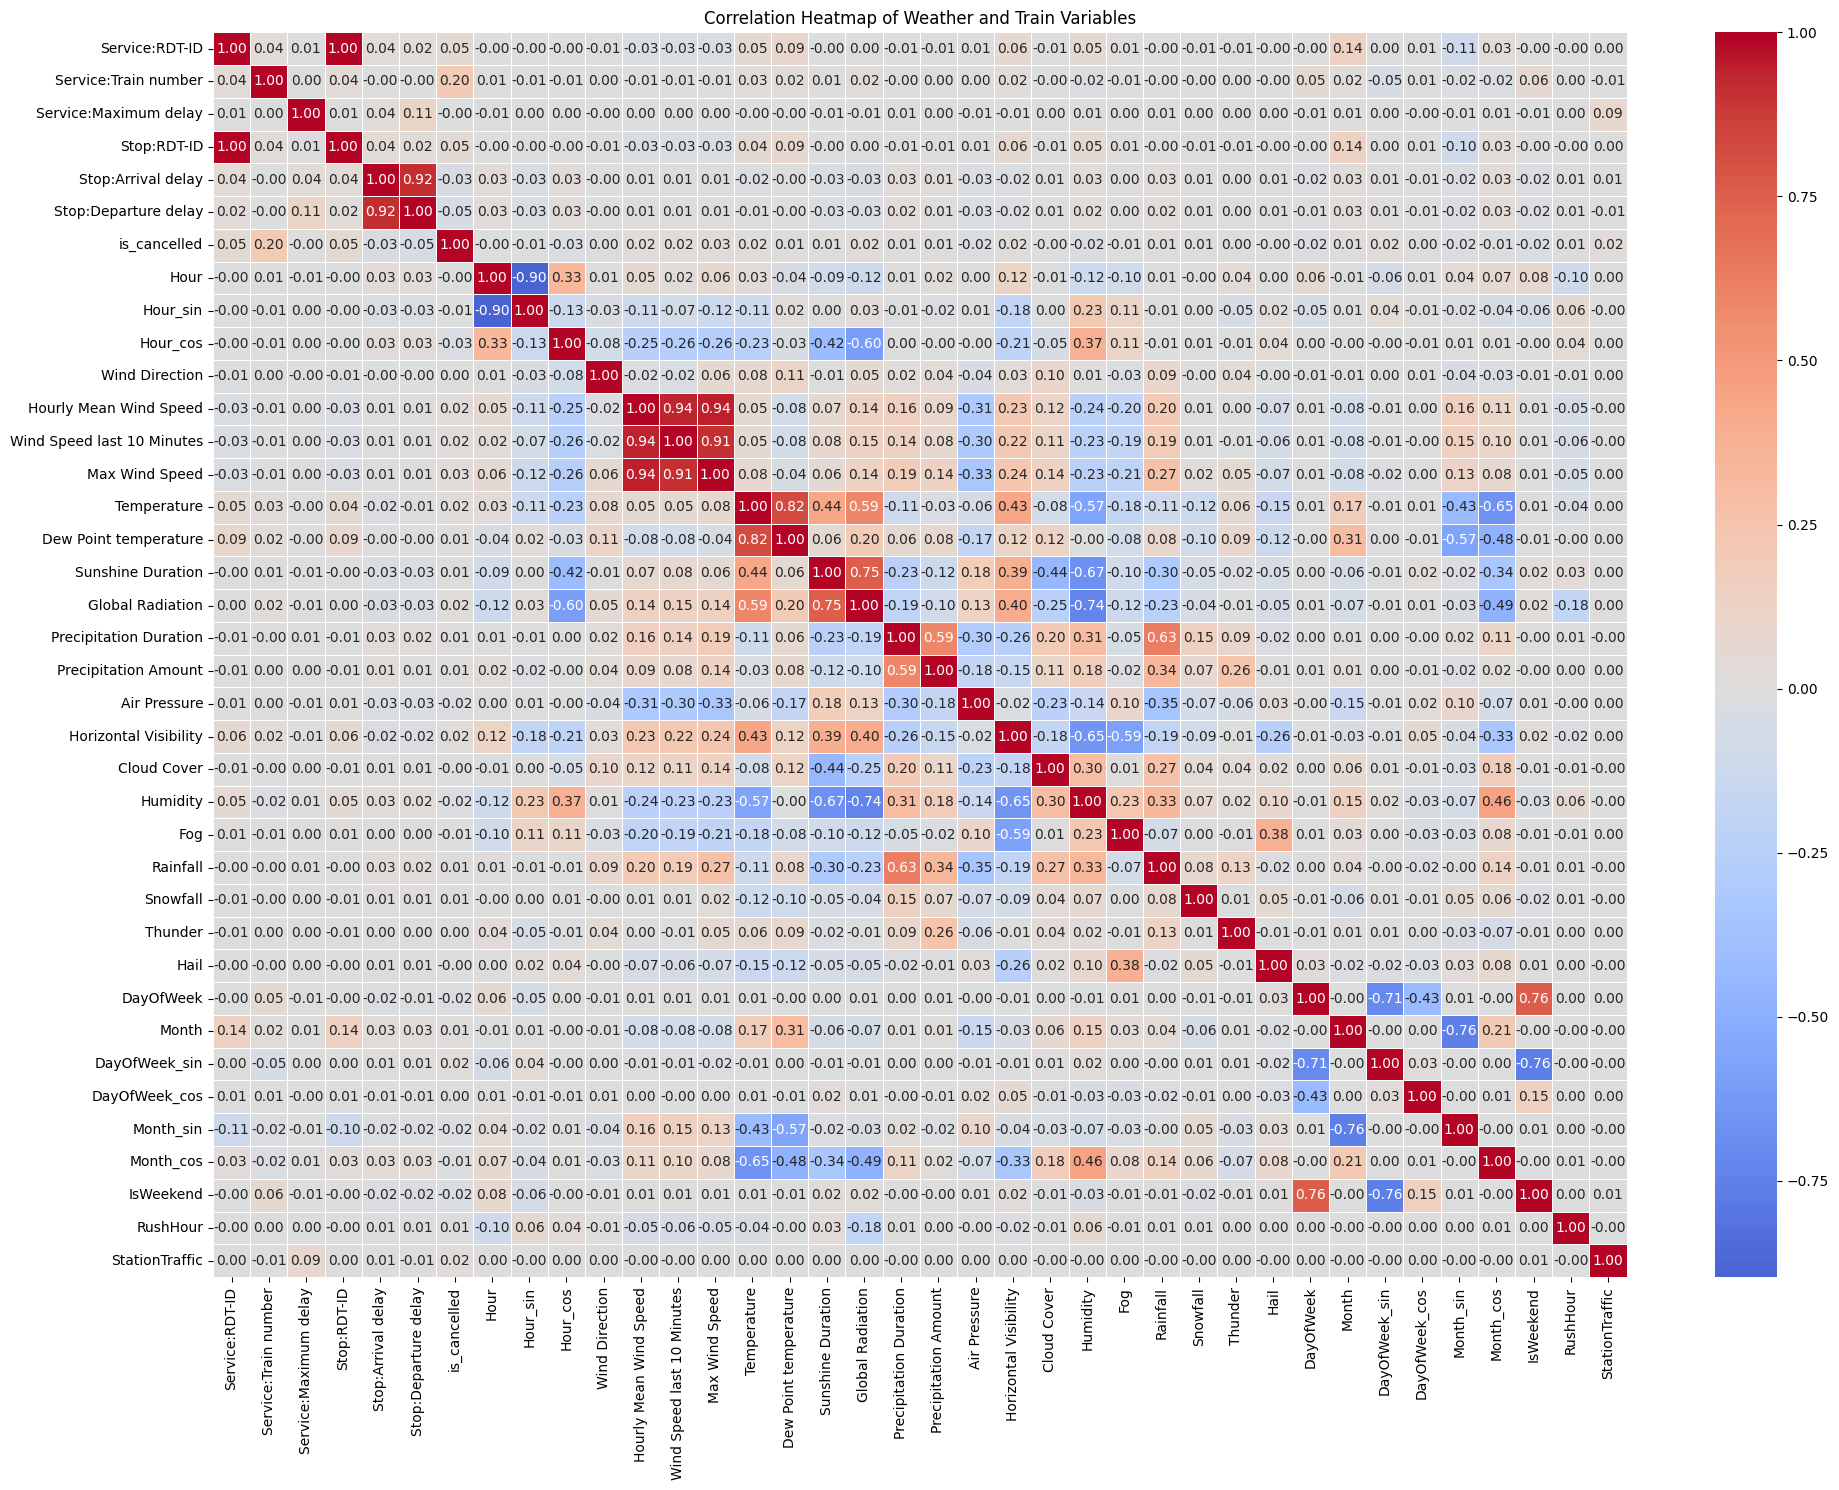

In [36]:
#heatmap: for correlation between numeric variables
corr = comb.select_dtypes(include=["number"]).corr()

plt.figure(figsize=(20, 15))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5, annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Weather and Train Variables")
plt.tight_layout()
plt.show()

In [37]:
comb.columns

Index(['Service:RDT-ID', 'Service:Date', 'Service:Type', 'Service:Company',
       'Service:Train number', 'Service:Completely cancelled',
       'Service:Partly cancelled', 'Service:Maximum delay', 'Stop:RDT-ID',
       'Stop:Station code', 'Stop:Station name', 'Stop:Arrival time',
       'Stop:Arrival delay', 'Stop:Arrival cancelled', 'Stop:Departure time',
       'Stop:Departure delay', 'Stop:Departure cancelled',
       'Stop:Platform change', 'Stop:Planned platform', 'Stop:Actual platform',
       'is_cancelled', 'Hour', 'Hour_sin', 'Hour_cos', 'YYYYMMDD',
       'Wind Direction', 'Hourly Mean Wind Speed',
       'Wind Speed last 10 Minutes', 'Max Wind Speed', 'Temperature',
       'Dew Point temperature', 'Sunshine Duration', 'Global Radiation',
       'Precipitation Duration', 'Precipitation Amount', 'Air Pressure',
       'Horizontal Visibility', 'Cloud Cover', 'Humidity', 'Fog', 'Rainfall',
       'Snowfall', 'Thunder', 'Hail', 'DayOfWeek', 'Month', 'DayOfWeek_sin',
       'Da

In [38]:
features = [
    "Service:RDT-ID",
    "Stop:Station code",
    "Hour",
    "DayOfWeek_sin",
    "DayOfWeek_cos",
    "Month_sin",
    "Month_cos",
    "IsWeekend",
    "RushHour",
    "StationTraffic",
    "Temperature",
    "Humidity",
    "Air Pressure",
    "Horizontal Visibility",
    "Cloud Cover",
    "Precipitation Amount",
    "Precipitation Duration",
    "Hourly Mean Wind Speed",
    "Max Wind Speed",
    "Fog",
    "Rainfall",
    "Snowfall",
    "Thunder",
    "Hail",
    "Service:Type"
]

target = "is_cancelled"

# Keep only feature + target columns in comb, drop everything else
requested_cols = features + [target]
missing_cols = [col for col in requested_cols if col not in comb.columns]

if missing_cols:
    print("Missing requested columns:", missing_cols)

present_cols = [col for col in requested_cols if col in comb.columns]
comb = comb.loc[:, present_cols].copy()

# Ensure features only contains columns that are still present
features = [col for col in features if col in comb.columns]

In [46]:
comb.columns

Index(['Service:RDT-ID', 'Stop:Station code', 'Hour', 'DayOfWeek_sin',
       'DayOfWeek_cos', 'Month_sin', 'Month_cos', 'IsWeekend', 'RushHour',
       'StationTraffic', 'Temperature', 'Humidity', 'Air Pressure',
       'Horizontal Visibility', 'Cloud Cover', 'Precipitation Amount',
       'Precipitation Duration', 'Hourly Mean Wind Speed', 'Max Wind Speed',
       'Fog', 'Rainfall', 'Snowfall', 'Thunder', 'Hail', 'Service:Type',
       'is_cancelled'],
      dtype='str')

In [53]:
print("Exporting Clean")
output_path = "C:/Users/johan/repos/master_thesis/combined_data_clean.csv"
comb.to_csv(output_path, index=False)
print(f"Done exporting")


Exporting Clean
Done exporting
